In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split,  TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Reproducibility

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# hyper-parameters
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 1e-3
VAL_SPLIT   = 0.1

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR    = "outputs_task1a"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


In [11]:

# loading adn preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download  MNIST training set
full_train = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

# split
n_val   = int(len(full_train) * VAL_SPLIT)
n_train = len(full_train) - n_val
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# test set
test_set = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"[INFO] Train: {n_train}  |  Val: {n_val}  |  Test: {len(test_set)}")

[INFO] Train: 54000  |  Val: 6000  |  Test: 10000


In [12]:
# CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

      # convolutional block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        # convolutional block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

      #FC layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(400, 64),
            #activation
            nn.ReLU(inplace=True),
            # regularisation
            nn.Dropout(0.4),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


In [13]:

model = CNN().to(DEVICE)

In [14]:
# count total  parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Total trainable parameters: {total_params:,}")
assert total_params <= 50_000, f"Parameter limit exceeded: {total_params}"

[INFO] Total trainable parameters: 27,610


In [15]:
# loss function
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)

# scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [16]:
#training
def train_epoch(loader):
    model.train()

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, 100.0 * correct / total

# Validation
def eval_epoch(loader):
    model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, 100.0 * correct / total

In [17]:
# storage for plotting
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n[INFO] Starting training…")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {va_loss:>8.4f} | {tr_acc:>8.2f}% | {va_acc:>7.2f}%")

# final test evaluation
_, test_acc = eval_epoch(test_loader)
print(f"\n[RESULT] Final Test Accuracy: {test_acc:.2f}%")

# Save trained model weights
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "mnist_cnn.pth"))



[INFO] Starting training…
 Epoch | Train Loss | Val Loss | Train Acc |  Val Acc
--------------------------------------------------------
     1 |     0.3301 |   0.0815 |    90.28% |   97.65%
     2 |     0.1221 |   0.0648 |    96.47% |   98.08%
     3 |     0.0975 |   0.0599 |    97.01% |   98.32%
     4 |     0.0878 |   0.0569 |    97.40% |   98.42%
     5 |     0.0761 |   0.0510 |    97.76% |   98.43%
     6 |     0.0672 |   0.0518 |    97.97% |   98.50%
     7 |     0.0618 |   0.0496 |    98.11% |   98.55%
     8 |     0.0574 |   0.0471 |    98.22% |   98.58%
     9 |     0.0528 |   0.0454 |    98.38% |   98.77%
    10 |     0.0455 |   0.0448 |    98.62% |   98.65%
    11 |     0.0441 |   0.0442 |    98.64% |   98.87%
    12 |     0.0418 |   0.0416 |    98.74% |   98.77%
    13 |     0.0395 |   0.0421 |    98.77% |   98.78%
    14 |     0.0359 |   0.0426 |    98.89% |   98.80%
    15 |     0.0362 |   0.0424 |    98.83% |   98.78%

[RESULT] Final Test Accuracy: 98.81%


[INFO] Saved training curves → outputs_task1a/task1a_curves.png


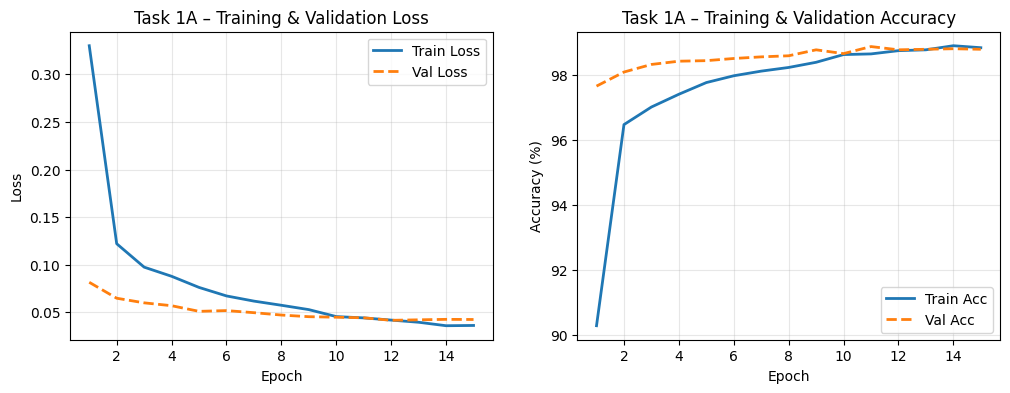

In [18]:
# plot training curves
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss subplot
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Task 1A – Training & Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy subplot
axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Task 1A – Training & Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "task1a_curves.png")
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
print(f"[INFO] Saved training curves → {curve_path}")
plt.show()

[INFO] Saved filter visualisation → outputs_task1a/task1a_filters.png


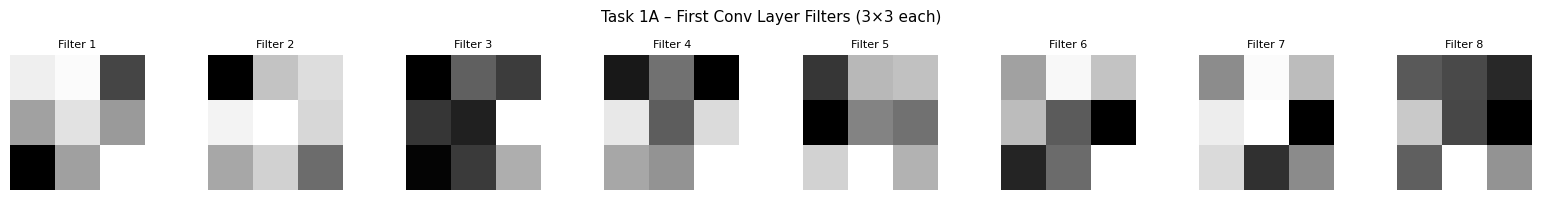

In [19]:
#  visualise first layer filters

# extract filter weights
filters = model.block1[0].weight.data.cpu().numpy()
n_filters = filters.shape[0]

fig, axes = plt.subplots(1, n_filters, figsize=(2 * n_filters, 2))
for i in range(n_filters):
    f = filters[i, 0]
    # normalise
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    axes[i].imshow(f_norm, cmap="gray", interpolation="nearest")
    axes[i].set_title(f"Filter {i+1}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Task 1A – First Conv Layer Filters (3×3 each)", fontsize=11)
plt.tight_layout()
filter_path = os.path.join(SAVE_DIR, "task1a_filters.png")
plt.savefig(filter_path, dpi=150, bbox_inches="tight")
print(f"[INFO] Saved filter visualisation → {filter_path}")
plt.show()




##Question 1 Task B

In [21]:
# config
SEED       = 42
BATCH_SIZE = 64
EPOCHS     = 15
LR         = 1e-3
VAL_SPLIT  = 0.1


In [24]:
DATA_DIR   = "."

In [23]:
import os
os.listdir()

['.config',
 'data',
 'train_biased.pt',
 'test_biased.pt',
 'test_unbiased.pt',
 'outputs_task1a',
 'sample_data']

In [26]:
SAVE_DIR   = "outputs_task1b"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")


[INFO] Using device: cuda


In [27]:
# data loading helpers
def load_pt_dataset(path: str) -> TensorDataset:
    raw = torch.load(path, map_location="cpu", weights_only=False)

    # support both tuple and dict formats
    if isinstance(raw, (list, tuple)):
        images, labels = raw[0], raw[1]
    elif isinstance(raw, dict):
        images = raw.get("data", raw.get("images"))
        labels = raw.get("labels", raw.get("targets"))
    else:
        raise ValueError(f"Unrecognised .pt format: {type(raw)}")

    # ensure correct datatypes
    images = images.float()
    labels = labels.long()

    # Normalise RGB channel
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images = (images - mean) / std

    return TensorDataset(images, labels)


print("[INFO] Loading C-MNIST datasets…")
train_path    = os.path.join(DATA_DIR, "train_biased.pt")
biased_path   = os.path.join(DATA_DIR, "test_biased.pt")
unbiased_path = os.path.join(DATA_DIR, "test_unbiased.pt")


[INFO] Loading C-MNIST datasets…


In [28]:
# check file
for p in [train_path, biased_path, unbiased_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"\n[ERROR] Missing file: {p}\n"
            "Please place the files!!!! "
            f"in '{DATA_DIR}' (set DATA_DIR at the top of this script)."
        )

full_train_ds   = load_pt_dataset(train_path)
test_biased_ds  = load_pt_dataset(biased_path)
test_unbiased_ds= load_pt_dataset(unbiased_path)

In [29]:
# split
n_val   = int(len(full_train_ds) * VAL_SPLIT)
n_train = len(full_train_ds) - n_val
train_ds, val_ds = random_split(
    full_train_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader    = DataLoader(train_ds,        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader      = DataLoader(val_ds,          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
biased_loader   = DataLoader(test_biased_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
unbiased_loader = DataLoader(test_unbiased_ds,batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"[INFO] Train: {n_train}  |  Val: {n_val}  "
      f"|  Test-biased: {len(test_biased_ds)}  |  Test-unbiased: {len(test_unbiased_ds)}")


[INFO] Train: 54000  |  Val: 6000  |  Test-biased: 10000  |  Test-unbiased: 10000


In [30]:
#model architecture

class ColoredCNN(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 10):
        super(ColoredCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


In [31]:
model = ColoredCNN(in_channels=3, num_classes=10).to(DEVICE)

In [32]:
# total parameters count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Trainable parameters: {total_params:,}")
assert total_params <= 50_000, f"Param limit exceeded: {total_params}"

[INFO] Trainable parameters: 27,754


In [33]:
# Loss
criterion = nn.CrossEntropyLoss()
# Optimiser
optimizer = optim.Adam(model.parameters(), lr=LR)
# Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [34]:
# Training
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(images)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n[INFO] Training on biased C-MNIST…")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {va_loss:>8.4f} | {tr_acc:>8.2f}% | {va_acc:>7.2f}%")



[INFO] Training on biased C-MNIST…
 Epoch | Train Loss | Val Loss | Train Acc |  Val Acc
--------------------------------------------------------
     1 |     0.2201 |   0.0616 |    94.81% |   98.15%
     2 |     0.0728 |   0.0409 |    97.91% |   98.68%
     3 |     0.0510 |   0.0386 |    98.45% |   98.90%
     4 |     0.0410 |   0.0355 |    98.79% |   99.08%
     5 |     0.0353 |   0.0307 |    98.92% |   99.03%
     6 |     0.0259 |   0.0252 |    99.23% |   99.28%
     7 |     0.0232 |   0.0258 |    99.26% |   99.25%
     8 |     0.0217 |   0.0251 |    99.35% |   99.37%
     9 |     0.0205 |   0.0249 |    99.39% |   99.30%
    10 |     0.0191 |   0.0255 |    99.42% |   99.28%
    11 |     0.0134 |   0.0245 |    99.60% |   99.33%
    12 |     0.0140 |   0.0240 |    99.56% |   99.32%
    13 |     0.0131 |   0.0231 |    99.59% |   99.30%
    14 |     0.0129 |   0.0249 |    99.61% |   99.30%
    15 |     0.0119 |   0.0228 |    99.64% |   99.37%


In [35]:
#  Evaluate  BOTH Test Sets
_, biased_acc   = run_epoch(biased_loader,   train=False)
_, unbiased_acc = run_epoch(unbiased_loader, train=False)

print(f"\n[RESULT] Test Accuracy (Biased test set)  : {biased_acc:.2f}%")
print(f"[RESULT] Test Accuracy (Unbiased test set): {unbiased_acc:.2f}%")
print(f"[RESULT] Accuracy drop due to shortcut learning: "
      f"{biased_acc - unbiased_acc:.2f} pp")


[RESULT] Test Accuracy (Biased test set)  : 99.52%
[RESULT] Test Accuracy (Unbiased test set): 92.54%
[RESULT] Accuracy drop due to shortcut learning: 6.98 pp


In [36]:
# Save model
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "cmnist_cnn.pth"))


[INFO] Saved training curves


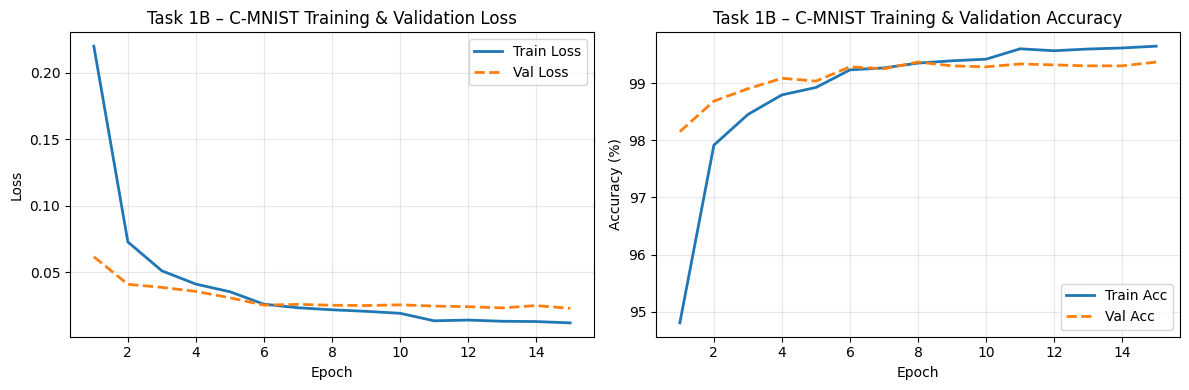

In [37]:
#  Plot Training Curves
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Task 1B – C-MNIST Training & Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Task 1B – C-MNIST Training & Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "task1b_curves.png"), dpi=150, bbox_inches="tight")
print("[INFO] Saved training curves")

[INFO] Saved sample image grids


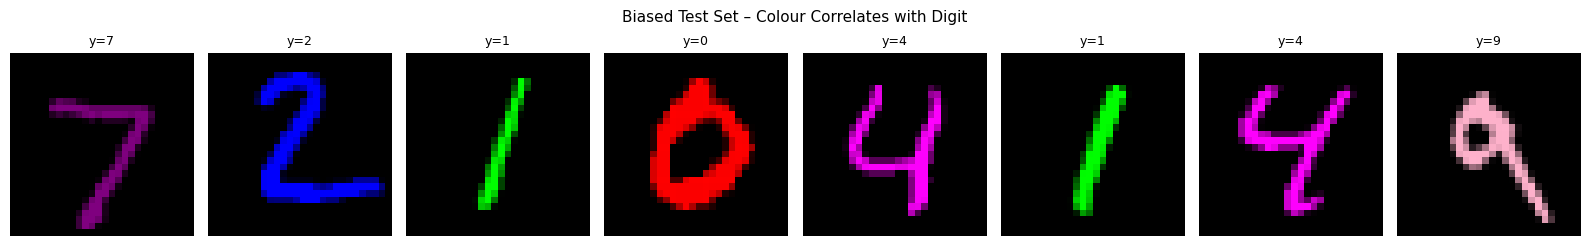

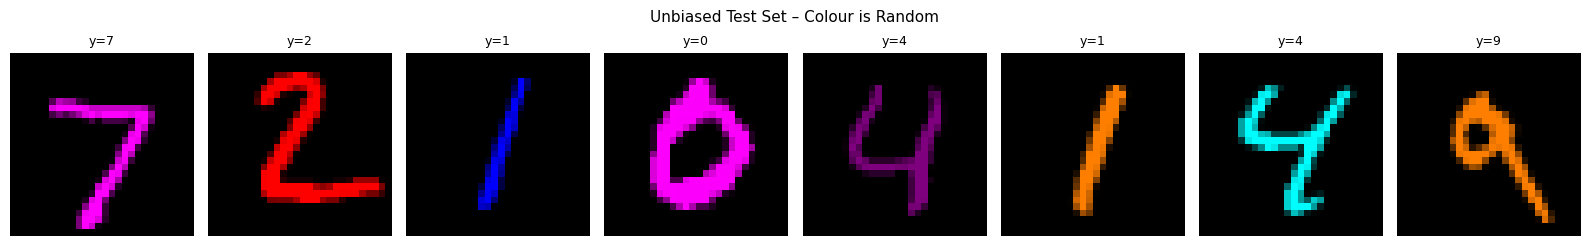

In [39]:
# visualise sample images
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    """Undo channel-wise normalisation for display purposes."""
    return (t * std_t + mean_t).clamp(0, 1)

def show_samples(loader, title, nrow=8):
    """Display the first nrow images from a DataLoader."""
    imgs, labels = next(iter(loader))
    imgs = imgs[:nrow]
    labels = labels[:nrow]

    fig, axes = plt.subplots(1, nrow, figsize=(2 * nrow, 2.5))
    for i in range(nrow):
        img = denorm(imgs[i]).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"y={labels[i].item()}", fontsize=9)
        axes[i].axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    return fig

fig1 = show_samples(biased_loader,   "Biased Test Set – Colour Correlates with Digit")
fig1.savefig(os.path.join(SAVE_DIR, "biased_samples.png"), dpi=150, bbox_inches="tight")

fig2 = show_samples(unbiased_loader, "Unbiased Test Set – Colour is Random")
fig2.savefig(os.path.join(SAVE_DIR, "unbiased_samples.png"), dpi=150, bbox_inches="tight")

print("[INFO] Saved sample image grids")
plt.show()


##TASK 2  Transfer Learning and Interpretability

In [40]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image


In [41]:
# Configuration
SEED        = 42
BATCH_SIZE  = 64
EPOCHS      = 10
LR          = 1e-3

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR    = "outputs_task2"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"[INFO] Device: {DEVICE}")

# STL-10 class names (used for GradCAM labels)
STL10_CLASSES = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

[INFO] Device: cuda


In [42]:
#  Data: STL-10
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# downloading data
print("[INFO] Loading STL-10 (downloading if needed)…")
train_set = torchvision.datasets.STL10(
    root="./data_stl10", split="train", download=True, transform=train_transform
)
test_set = torchvision.datasets.STL10(
    root="./data_stl10", split="test",  download=True, transform=test_transform
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"[INFO] Train: {len(train_set)}  |  Test: {len(test_set)}")


[INFO] Loading STL-10 (downloading if needed)…


100%|██████████| 2.64G/2.64G [01:53<00:00, 23.2MB/s]


[INFO] Train: 5000  |  Test: 8000


In [43]:
# loss & optimiser
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5, 8], gamma=0.1)


[INFO] Loading pretrained ResNet-18…
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


[INFO] Trainable params: 5,130  |  Frozen params: 11,176,512


In [44]:
#  Training
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(images)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

print("\n[INFO] Training classification head…")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Test Loss':>9} | {'Train Acc':>9} | {'Test Acc':>8}")
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader,  train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {te_loss:>9.4f} | {tr_acc:>8.2f}% | {te_acc:>7.2f}%")

print(f"\n[RESULT] Final STL-10 Test Accuracy: {history['test_acc'][-1]:.2f}%")
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "resnet18_stl10.pth"))



[INFO] Training classification head…
 Epoch | Train Loss | Test Loss | Train Acc | Test Acc
----------------------------------------------------------
     1 |     2.5751 |    2.6551 |     9.52% |    9.66%
     2 |     2.5883 |    2.6476 |     9.46% |    9.46%
     3 |     2.5781 |    2.6267 |     9.18% |    9.80%
     4 |     2.5845 |    2.6339 |     9.52% |    9.70%
     5 |     2.5811 |    2.6597 |    10.06% |    9.05%
     6 |     2.5804 |    2.6442 |    10.20% |    9.45%
     7 |     2.5806 |    2.6517 |     9.70% |    9.69%
     8 |     2.5800 |    2.6391 |     8.98% |    9.62%
     9 |     2.5774 |    2.6394 |     9.94% |    9.59%
    10 |     2.5880 |    2.6338 |     9.64% |    9.39%

[RESULT] Final STL-10 Test Accuracy: 9.39%


[INFO] Saved training curves


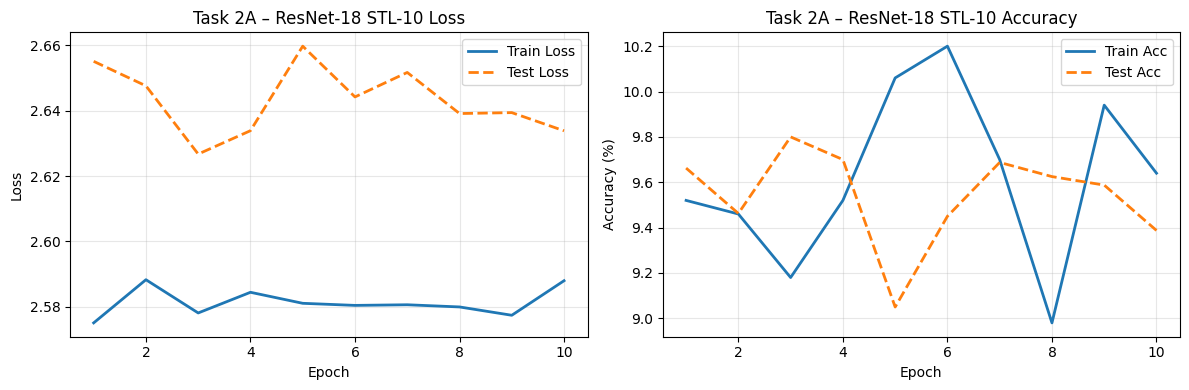

In [45]:
# plot training curves
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, history["test_loss"],  label="Test Loss",  linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Task 2A – ResNet-18 STL-10 Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(epochs_range, history["test_acc"],  label="Test Acc",  linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Task 2A – ResNet-18 STL-10 Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "task2a_curves.png"), dpi=150, bbox_inches="tight")
print("[INFO] Saved training curves")


In [46]:
# PART B: GradCAM

class GradCAM:

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        self.gradients    = None

        self._fwd_hook = target_layer.register_forward_hook(self._save_activations)

        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x: torch.Tensor, class_idx: int = None) -> np.ndarray:
        self.model.eval()

          # forward pass
        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()

        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        # compute CAM
        grads = self.gradients[0]
        acts  = self.activations[0]

        weights = grads.mean(dim=[1, 2])

        cam = torch.zeros(acts.shape[1:], device=acts.device)  # (H', W')
        for k, w in enumerate(weights):
            cam += w * acts[k]

        cam = torch.relu(cam)

        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = torch.nn.functional.interpolate(
            cam, size=(96, 96), mode="bilinear", align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()

        # Normalise
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, class_idx

    def remove(self):
        """Deregister hooks to avoid memory leaks."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()



In [48]:
# collect correctly and incorrectly classified images

def collect_examples(loader, n_correct=2, n_wrong=2):
    """
    Scan test batches and collect the first n_correct correct predictions
    and the first n_wrong incorrect predictions.

    Returns list of dicts: {image, true_label, pred_label, correct}
    """
    model.eval()
    examples = {"correct": [], "wrong": []}

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            preds  = logits.argmax(1)

            for i in range(len(images)):
                is_correct = (preds[i] == labels[i]).item()
                key = "correct" if is_correct else "wrong"

                if len(examples[key]) < (n_correct if is_correct else n_wrong):
                    examples[key].append({
                        "image":      images[i].cpu(),
                        "true_label": labels[i].item(),
                        "pred_label": preds[i].item(),
                        "correct":    is_correct
                    })

            # Stop as soon as we have enough of each type
            if len(examples["correct"]) >= n_correct and len(examples["wrong"]) >= n_wrong:
                break

    return examples["correct"][:n_correct] + examples["wrong"][:n_wrong]


examples = collect_examples(test_loader, n_correct=2, n_wrong=2)
print(f"[INFO] Collected {len(examples)} examples (2 correct, 2 incorrect) for GradCAM")


[INFO] Collected 4 examples (2 correct, 2 incorrect) for GradCAM


In [49]:
# generate GradCAM heatmaps

gcam = GradCAM(model, target_layer=model.layer4[-1])

mean_t = torch.tensor(imagenet_mean).view(3, 1, 1)
std_t  = torch.tensor(imagenet_std).view(3, 1, 1)

def denorm(t):
    return (t * std_t + mean_t).clamp(0, 1)

def overlay_cam(image_tensor, cam, alpha=0.5):
    # convert image to numpy HWC
    img_np = denorm(image_tensor).permute(1, 2, 0).numpy()  # (H, W, 3)

    # Apply a colourmap to the CAM
    heatmap = cm.jet(cam)[:, :, :3]

    overlay = alpha * heatmap + (1 - alpha) * img_np
    overlay = np.clip(overlay, 0, 1)
    return overlay


[INFO] Saved GradCAM figure → outputs_task2/task2b_gradcam.png


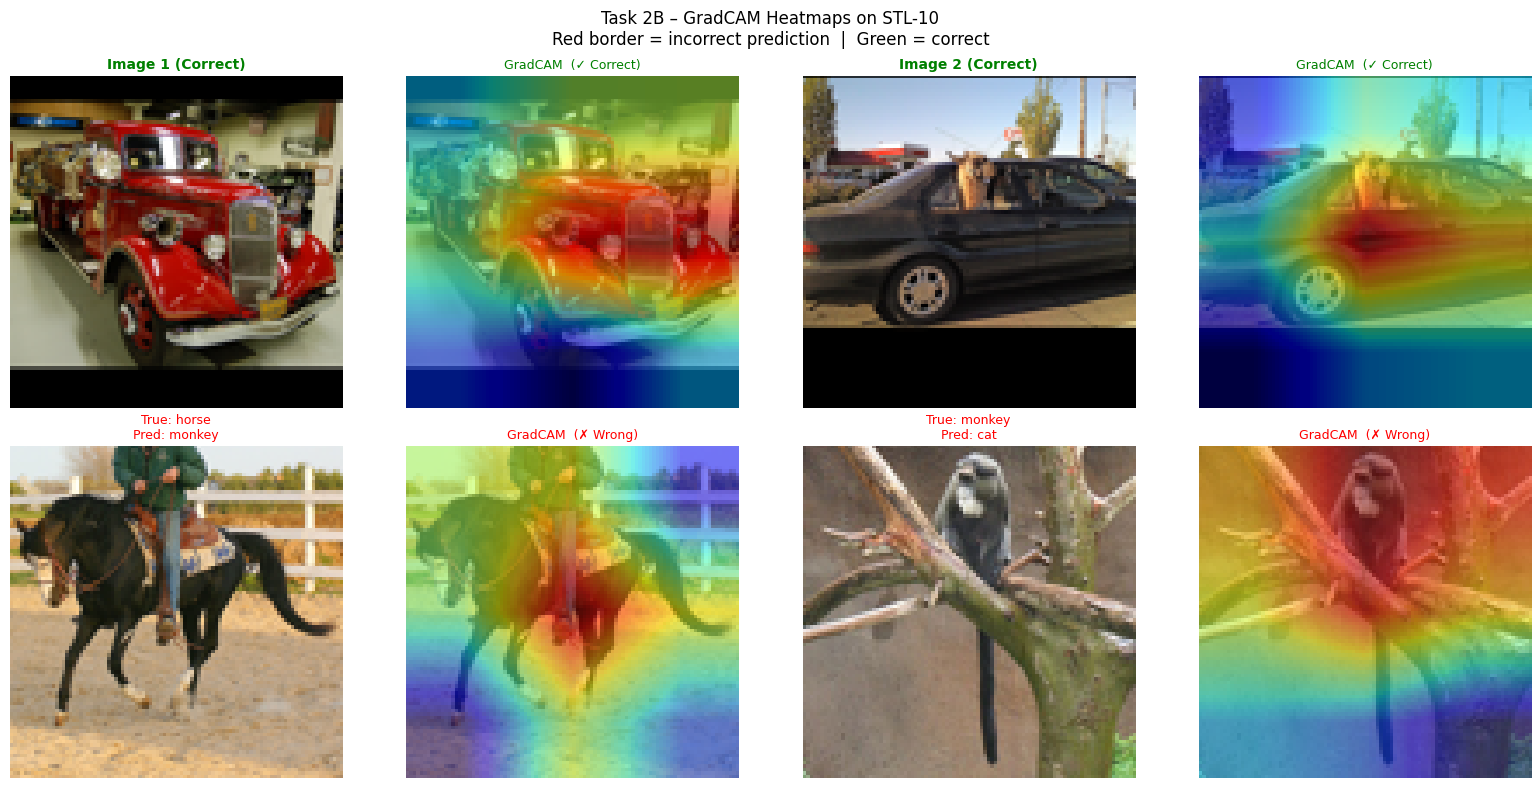

In [51]:
# visualise and save GradCAM results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, ex in enumerate(examples):
    row = idx // 2   # 0 or 1
    col = (idx % 2) * 2  # 0 or 2

    img  = ex["image"]
    true = ex["true_label"]
    pred = ex["pred_label"]
    ok   = ex["correct"]

    img_in = img.unsqueeze(0).to(DEVICE)
    img_in.requires_grad_(True)

    with torch.enable_grad():
        cam, pred_idx = gcam(img_in, class_idx=pred)

    overlay = overlay_cam(img, cam)

    # show original image
    img_show = denorm(img).permute(1, 2, 0).numpy()
    color = "green" if ok else "red"
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(
        f"True: {STL10_CLASSES[true]}\nPred: {STL10_CLASSES[pred]}",
        color=color, fontsize=9
    )
    axes[row, col].axis("off")

    # show GradCAM overlay
    axes[row, col + 1].imshow(overlay)
    axes[row, col + 1].set_title(
        f"GradCAM  ({'✓ Correct' if ok else '✗ Wrong'})",
        color=color, fontsize=9
    )
    axes[row, col + 1].axis("off")

for ax, title in zip(axes[0, ::2], ["Image 1 (Correct)", "Image 2 (Correct)"]):
    ax.set_title(title, fontsize=10, fontweight="bold")

plt.suptitle("Task 2B – GradCAM Heatmaps on STL-10\n"
             "Red border = incorrect prediction  |  Green = correct", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "task2b_gradcam.png"), dpi=150, bbox_inches="tight")
print(f"[INFO] Saved GradCAM figure → {os.path.join(SAVE_DIR, 'task2b_gradcam.png')}")

gcam.remove()

plt.show()
